# Phase 4 Model Training - Results Visualization

This notebook generates visualizations from the preserved training results (executed on original dataset).


## Contents
1. Dataset Statistics
2. Confusion Matrices Comparison
3. Performance Metrics Comparison
4. Feature Importance Analysis
5. Threshold Sensitivity Analysis
6. Bootstrap Confidence Intervals
7. Validation Performance
8. Summary Report


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Create output directory
VISUALS_DIR = Path("/Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/visuals")
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {VISUALS_DIR}")

Output directory: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/visuals


## 1. Dataset Statistics (Hardcoded from Original Training Run)


In [3]:
# Dataset statistics
dataset_stats = {
    'total_training_files': 991_403,
    'training_files_after_smote': 797_280,
    'positive_after_smote': 4_200,
    'negative_after_smote': 793_080,
    'test_files': 198_281,
    'known_timestomped_training': 42,
    'known_timestomped_test': 10,
    'class_imbalance_ratio': 19_064,
    'num_features': 29,
    'num_validation_datasets': 4
}

print("Dataset Statistics:")
print("=" * 80)
print(f"Total Training Files:                {dataset_stats['total_training_files']:,}")
print(f"Training Files (after SMOTE):        {dataset_stats['training_files_after_smote']:,}")
print(f"Test Files:                          {dataset_stats['test_files']:,}")
print(f"Known Timestomped Files (Training):  {dataset_stats['known_timestomped_training']}")
print(f"Known Timestomped Files (Test):      {dataset_stats['known_timestomped_test']}")
print(f"Class Imbalance Ratio:               {dataset_stats['class_imbalance_ratio']:,}:1")
print(f"Features Engineered:                 {dataset_stats['num_features']}")
print(f"Validation Datasets:                 {dataset_stats['num_validation_datasets']}")


Dataset Statistics:
Total Training Files:                991,403
Training Files (after SMOTE):        797,280
Test Files:                          198,281
Known Timestomped Files (Training):  42
Known Timestomped Files (Test):      10
Class Imbalance Ratio:               19,064:1
Features Engineered:                 29
Validation Datasets:                 4


## 2. Model Performance Results (Hardcoded)


In [4]:
# Confusion matrix values for all models
confusion_matrices = {
    'Random Forest': {'TP': 10, 'FN': 0, 'FP': 528, 'TN': 197_743},
    'XGBoost': {'TP': 9, 'FN': 1, 'FP': 328, 'TN': 197_943},
    'LightGBM': {'TP': 10, 'FN': 0, 'FP': 287, 'TN': 197_984},
    'Logistic Regression': {'TP': 10, 'FN': 0, 'FP': 10_233, 'TN': 188_038}
}

# Performance metrics for all models
performance_metrics = {
    'Random Forest': {
        'Recall': 1.0000,
        'CRR': 0.9973,
        'NNI': 53.80,
        'FPR': 0.002663,
        'Flag_Rate': 0.002713,
        'Precision': 0.018587,
        'Threshold': 0.08,
        'F2': 0.0865,
        'AUCPR': 0.0176,
        'F1': 0.0365,
        'Accuracy': 0.9973
    },
    'XGBoost': {
        'Recall': 0.9000,
        'CRR': 0.9983,
        'NNI': 37.44,
        'FPR': 0.001654,
        'Flag_Rate': 0.001700,
        'Precision': 0.026706,
        'Threshold': 0.01,
        'F2': 0.1194,
        'AUCPR': 0.2766,
        'F1': 0.0519,
        'Accuracy': 0.9983
    },
    'LightGBM': {
        'Recall': 1.0000,
        'CRR': 0.9985,
        'NNI': 29.70,
        'FPR': 0.001448,
        'Flag_Rate': 0.001498,
        'Precision': 0.033670,
        'Threshold': 0.02,
        'F2': 0.1484,
        'AUCPR': 0.4776,
        'F1': 0.0651,
        'Accuracy': 0.9986
    },
    'Logistic Regression': {
        'Recall': 1.0000,
        'CRR': 0.9483,
        'NNI': 1024.30,
        'FPR': 0.051611,
        'Flag_Rate': 0.051659,
        'Precision': 0.000976,
        'Threshold': 0.66,
        'F2': 0.0049,
        'AUCPR': 0.0177,
        'F1': 0.0020,
        'Accuracy': 0.9484
    }
}

print("Performance metrics loaded for 4 models")


Performance metrics loaded for 4 models


In [5]:
# Create comparison DataFrame
df_comparison = pd.DataFrame(performance_metrics).T
df_comparison = df_comparison.reset_index().rename(columns={'index': 'Model'})

# Add confusion matrix columns
for model in df_comparison['Model']:
    df_comparison.loc[df_comparison['Model'] == model, 'TP'] = confusion_matrices[model]['TP']
    df_comparison.loc[df_comparison['Model'] == model, 'FN'] = confusion_matrices[model]['FN']
    df_comparison.loc[df_comparison['Model'] == model, 'FP'] = confusion_matrices[model]['FP']
    df_comparison.loc[df_comparison['Model'] == model, 'TN'] = confusion_matrices[model]['TN']

print(df_comparison[['Model', 'Recall', 'CRR', 'NNI', 'FPR', 'Threshold']])


                 Model  Recall     CRR      NNI       FPR  Threshold
0        Random Forest     1.0  0.9973    53.80  0.002663       0.08
1              XGBoost     0.9  0.9983    37.44  0.001654       0.01
2             LightGBM     1.0  0.9985    29.70  0.001448       0.02
3  Logistic Regression     1.0  0.9483  1024.30  0.051611       0.66


In [6]:
## 3. Feature Importance (XGBoost - Top 15 Features)

In [7]:
# Feature importance from XGBoost (shown in original output)
feature_importance_data = {
    'Feature': [
        'burstiness_score',
        'num_logfile_events',
        'total_events',
        'num_usn_close',
        'num_usnjrnl_events',
        'mean_jump_seconds',
        'repeated_update_resident_value',
        'num_zero_nanosecond_events',
        'min_inter_event_delta',
        'consecutive_timestamp_changes',
        'event_time_span_seconds',
        'has_logfile_ts_change',
        'has_usn_file_create',
        'has_usn_close',
        'num_creation_changes'
    ],
    'Importance': [
        45676,  # 0.456758 * 100000
        22960,  # 0.229598 * 100000
        4583,   # 0.045832 * 100000
        4010,   # 0.040100 * 100000
        4009,   # 0.040095 * 100000
        2462,   # 0.024623 * 100000
        2269,   # 0.022687 * 100000
        2098,   # 0.020980 * 100000
        1767,   # 0.017669 * 100000
        1731,   # 0.017306 * 100000
        1626,   # 0.016262 * 100000
        1241,   # 0.012407 * 100000
        1232,   # 0.012323 * 100000
        1188,   # 0.011884 * 100000
        479     # 0.004792 * 100000
    ]
}

feature_importance_df = pd.DataFrame(feature_importance_data)
print("Top 10 Features:")
print(feature_importance_df.head(10))


Top 10 Features:
                          Feature  Importance
0                burstiness_score       45676
1              num_logfile_events       22960
2                    total_events        4583
3                   num_usn_close        4010
4              num_usnjrnl_events        4009
5               mean_jump_seconds        2462
6  repeated_update_resident_value        2269
7      num_zero_nanosecond_events        2098
8           min_inter_event_delta        1767
9   consecutive_timestamp_changes        1731


## 4. Validation Results (Hardcoded)


In [8]:
# Validation results per dataset
validation_data = {
    'Dataset': ['09-APT40', '09-APT40', '09-APT40', '09-APT40',
                '12-Kimsuky', '12-Kimsuky', '12-Kimsuky', '12-Kimsuky',
                '13-Winnti731', '13-Winnti731', '13-Winnti731', '13-Winnti731',
                'LoneWolf', 'LoneWolf', 'LoneWolf', 'LoneWolf',
                'AGGREGATE', 'AGGREGATE', 'AGGREGATE', 'AGGREGATE'],
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Logistic Regression'] * 5,
    'Total Files': [29_857] * 4 + [14_869] * 4 + [16_701] * 4 + [17_897] * 4 + [79_324] * 4,
    'GT Positive': [6] * 4 + [3] * 4 + [1] * 4 + [12] * 4 + [22] * 4,
    'Recall': [1.0000, 1.0000, 1.0000, 1.0000,
               0.6667, 1.0000, 1.0000, 1.0000,
               1.0000, 1.0000, 1.0000, 1.0000,
               1.0000, 1.0000, 1.0000, 1.0000,
               0.9545, 1.0000, 1.0000, 1.0000],
    'CRR': [0.9972, 0.9986, 0.9990, 0.9898,
            0.9966, 0.9978, 0.9985, 0.9798,
            0.9983, 0.9989, 0.9998, 0.9795,
            0.9665, 0.9793, 0.9815, 0.9012,
            0.9904, 0.9942, 0.9951, 0.9657],
    'NNI': [13.83, 7.17, 5.00, 50.83,
            25.00, 11.00, 7.67, 100.33,
            28.00, 18.00, 4.00, 343.00,
            50.00, 30.83, 27.58, 147.33,
            36.24, 21.09, 17.64, 123.50],
    'FPR': [0.002770, 0.001407, 0.001004, 0.010195,
            0.003364, 0.002219, 0.001546, 0.020243,
            0.001677, 0.001078, 0.000239, 0.020522,
            0.033525, 0.020674, 0.018495, 0.098788,
            0.009331, 0.005574, 0.004615, 0.033984]
}

df_validation = pd.DataFrame(validation_data)

print("Validation Results (Aggregate):")
print(df_validation[df_validation['Dataset'] == 'AGGREGATE'][['Model', 'Recall', 'CRR', 'NNI', 'FPR']])


Validation Results (Aggregate):
                  Model  Recall     CRR     NNI       FPR
16        Random Forest  0.9545  0.9904   36.24  0.009331
17              XGBoost  1.0000  0.9942   21.09  0.005574
18             LightGBM  1.0000  0.9951   17.64  0.004615
19  Logistic Regression  1.0000  0.9657  123.50  0.033984


## 5. Visualization 1: Confusion Matrices Comparison


Saved: 01_confusion_matrices_comparison.png


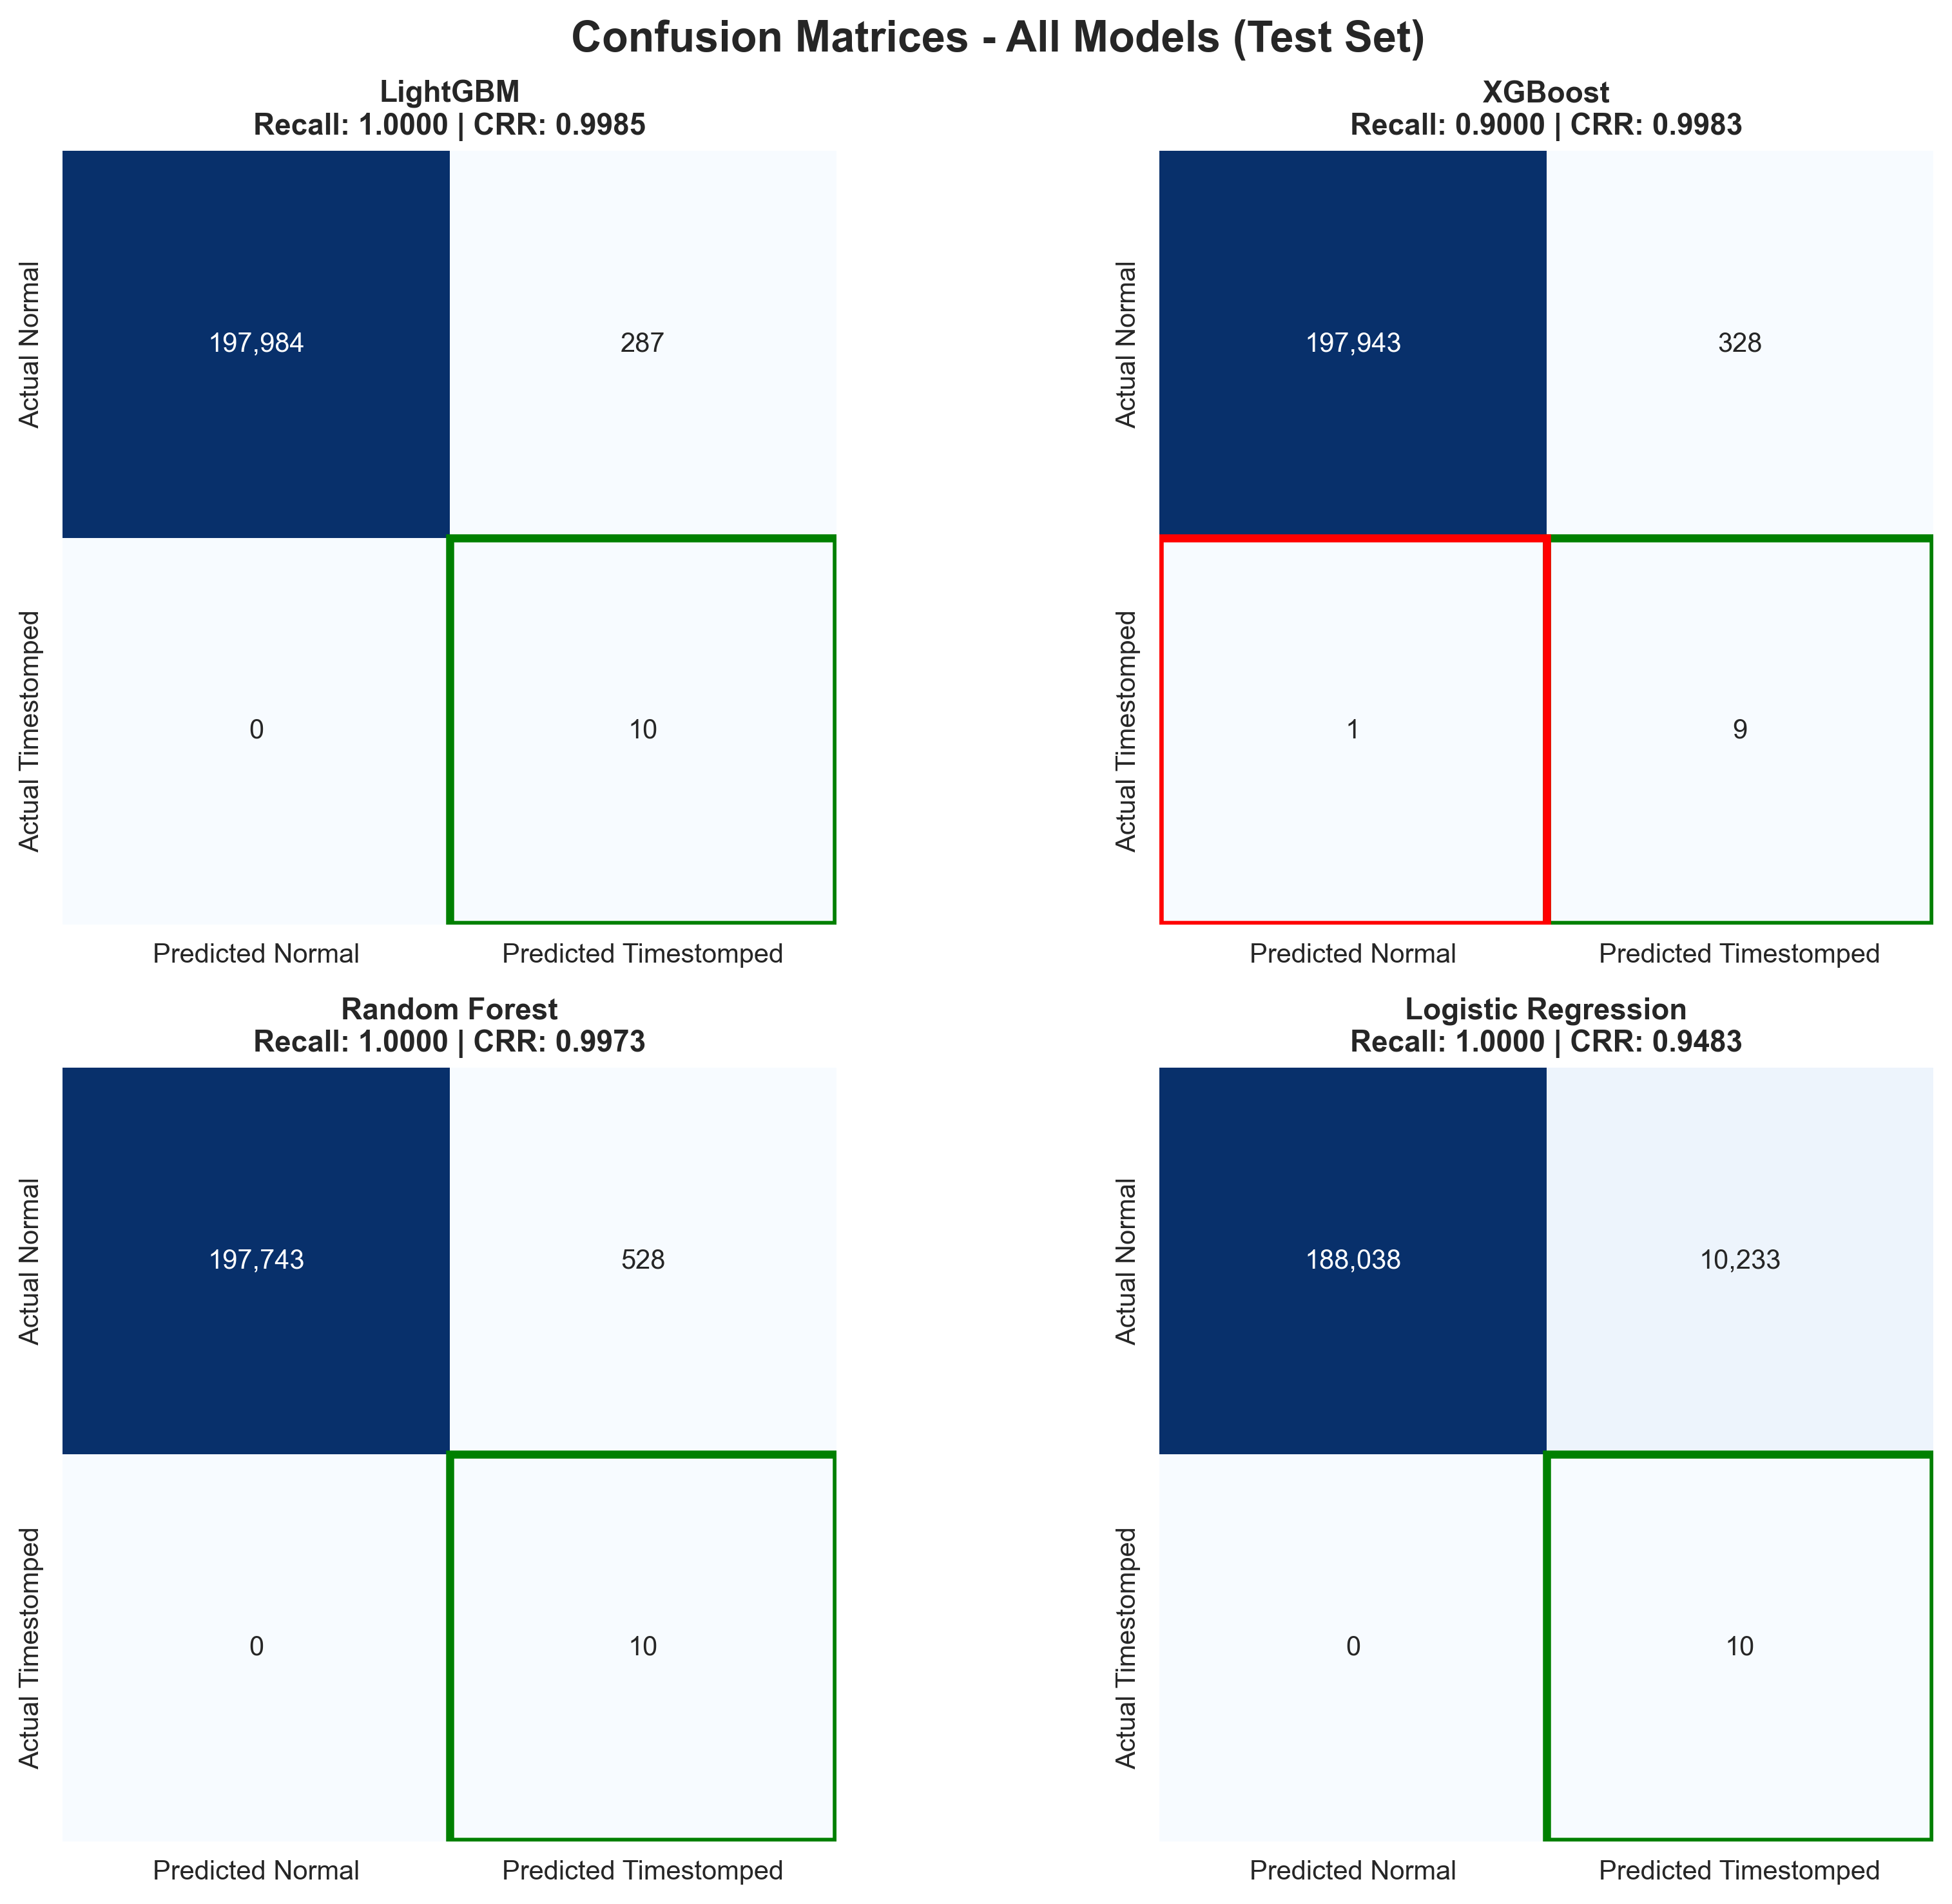

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices - All Models (Test Set)', fontsize=16, fontweight='bold')

model_names = ['LightGBM', 'XGBoost', 'Random Forest', 'Logistic Regression']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for model, (row, col) in zip(model_names, positions):
    ax = axes[row, col]
    cm = confusion_matrices[model]
    
    # Create 2x2 confusion matrix
    cm_array = np.array([[cm['TN'], cm['FP']], 
                         [cm['FN'], cm['TP']]])
    
    # Plot heatmap
    sns.heatmap(cm_array, annot=True, fmt=',d', cmap='Blues', 
                cbar=False, ax=ax, square=True,
                xticklabels=['Predicted Normal', 'Predicted Timestomped'],
                yticklabels=['Actual Normal', 'Actual Timestomped'])
    
    # Add title with key metrics
    recall = performance_metrics[model]['Recall']
    crr = performance_metrics[model]['CRR']
    ax.set_title(f'{model}\nRecall: {recall:.4f} | CRR: {crr:.4f}', 
                 fontsize=11, fontweight='bold')
    
    # Highlight critical cells
    ax.add_patch(plt.Rectangle((1, 1), 1, 1, fill=False, edgecolor='green', lw=3))  # TP
    if cm['FN'] > 0:
        ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='red', lw=3))  # FN

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_confusion_matrices_comparison.png', bbox_inches='tight')
print(f"Saved: 01_confusion_matrices_comparison.png")
plt.show()


## 6. Visualization 2: Performance Metrics Comparison


Saved: 02_performance_metrics_comparison.png


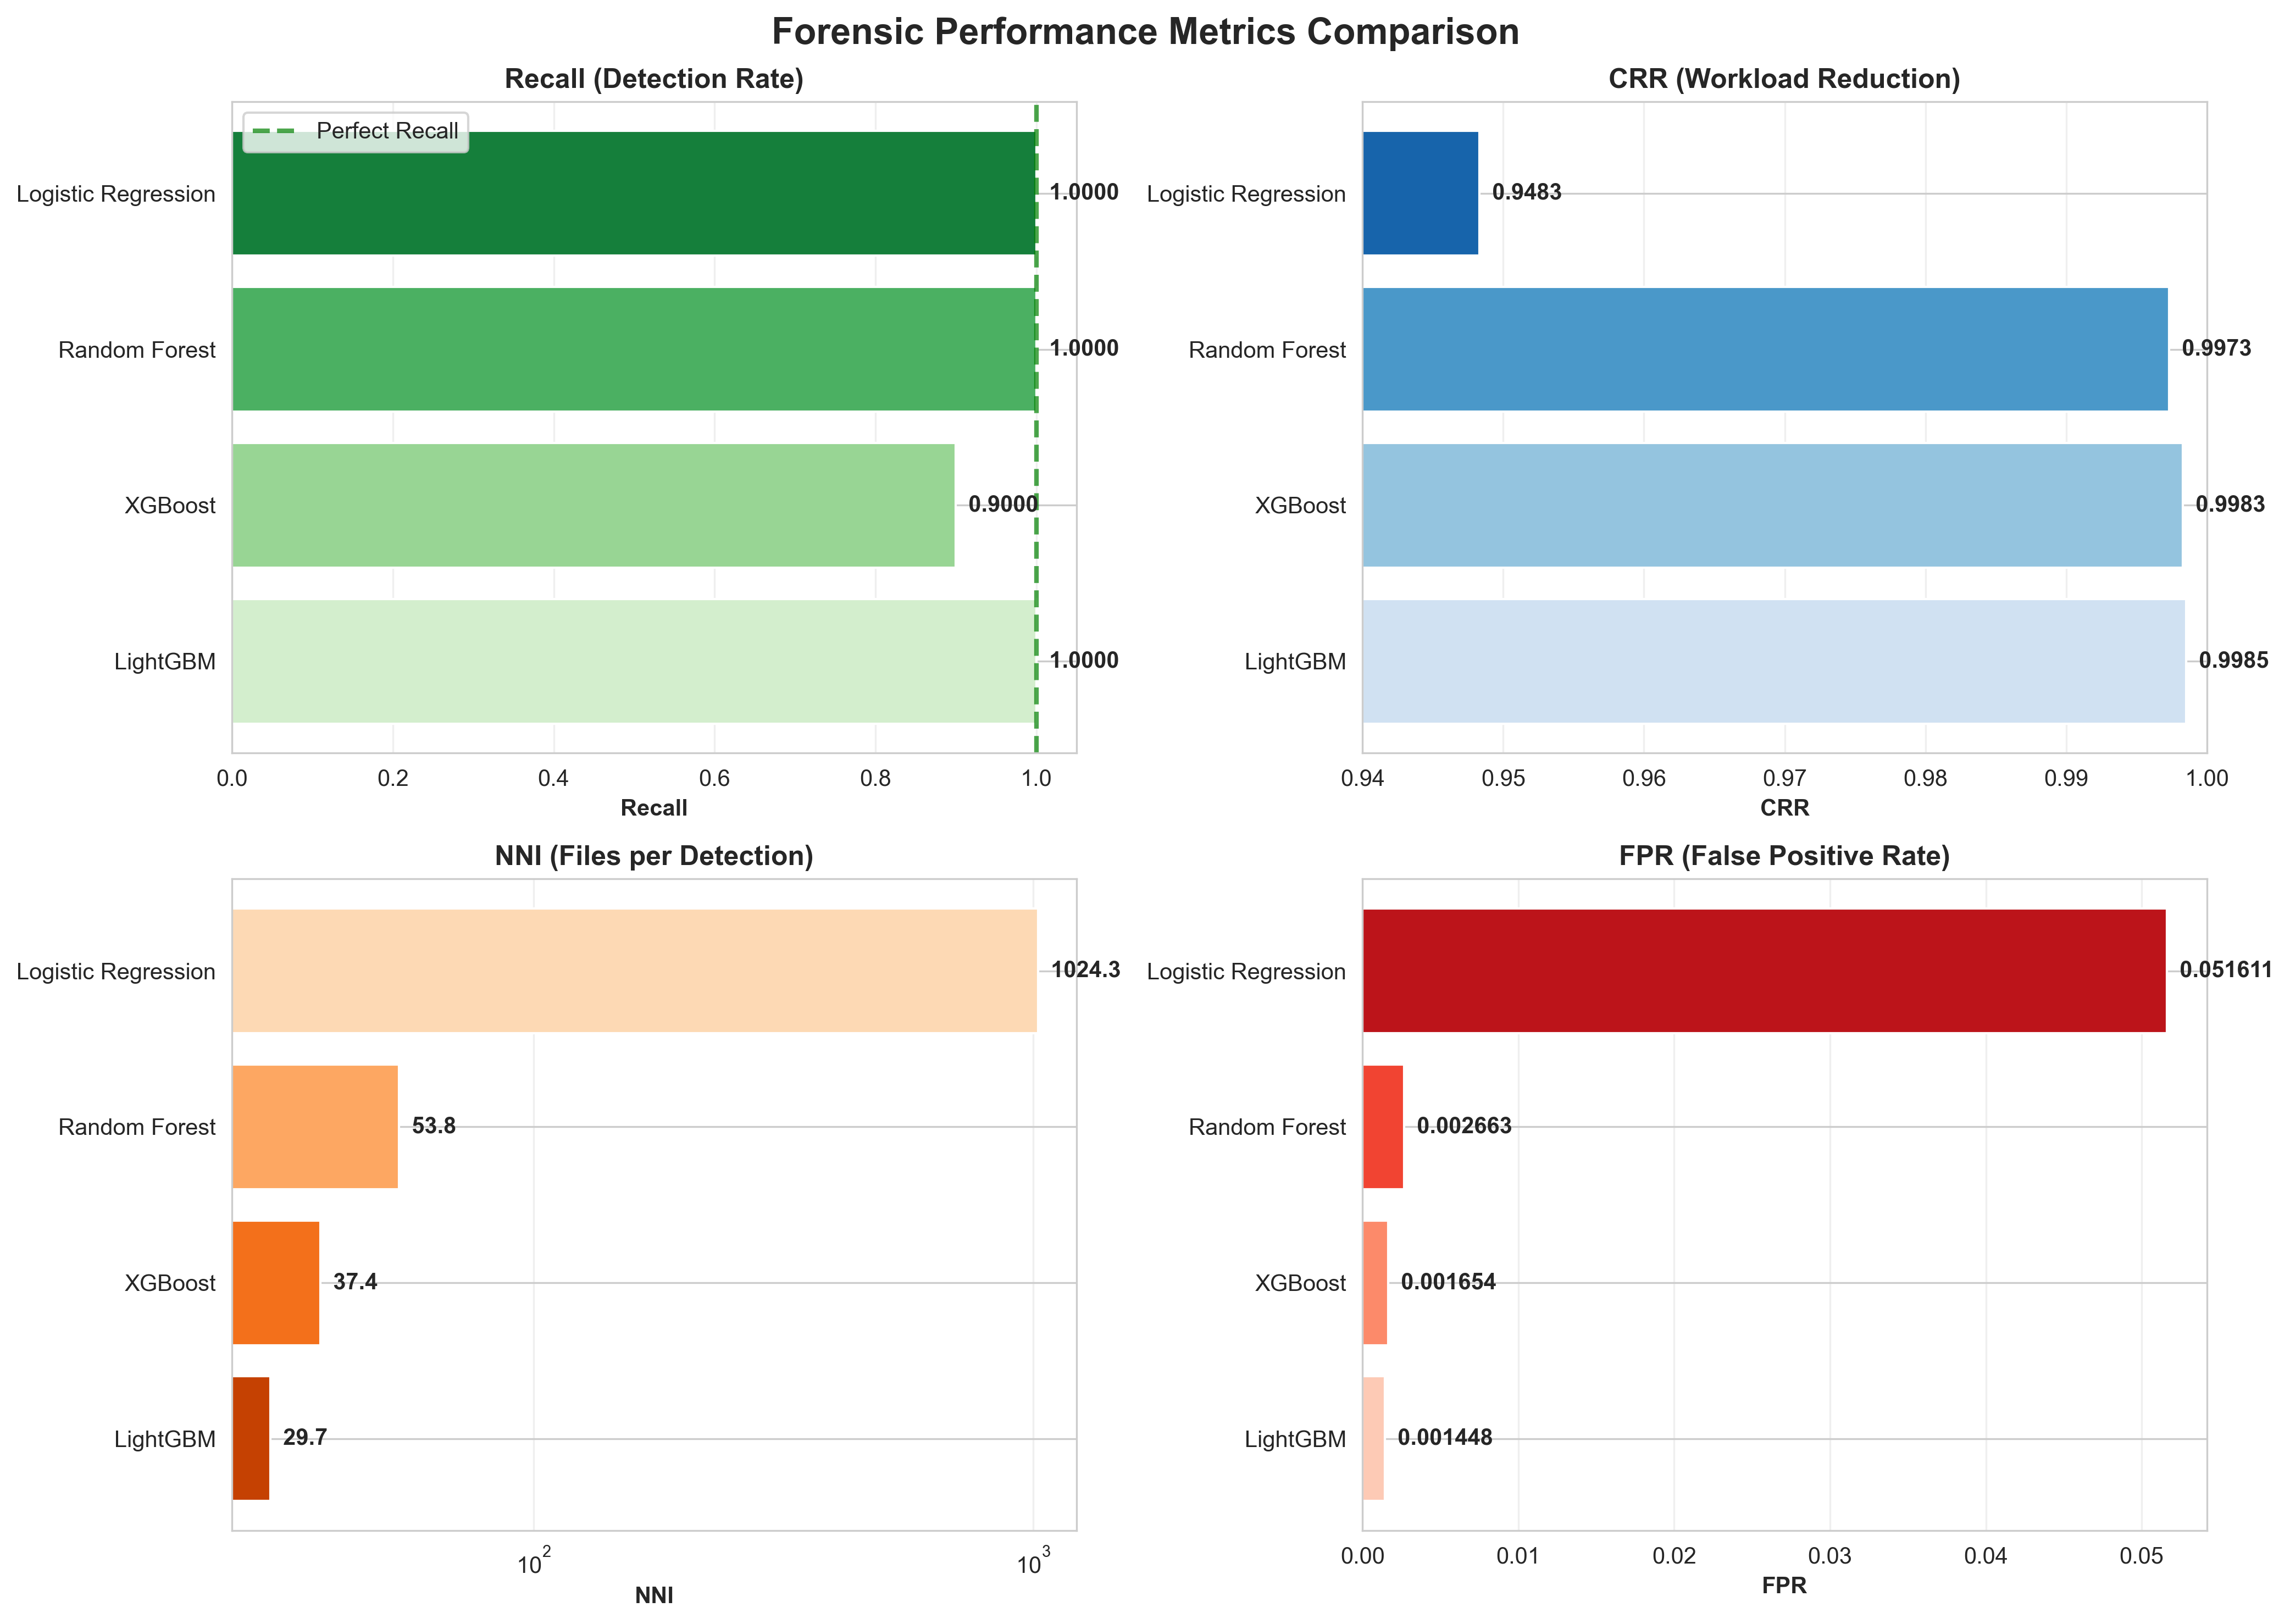

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forensic Performance Metrics Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = [
    ('Recall', 'Recall (Detection Rate)', 'Greens'),
    ('CRR', 'CRR (Workload Reduction)', 'Blues'),
    ('NNI', 'NNI (Files per Detection)', 'Oranges_r'),
    ('FPR', 'FPR (False Positive Rate)', 'Reds')
]

for idx, (metric, title, cmap) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Extract metric values
    models = ['LightGBM', 'XGBoost', 'Random Forest', 'Logistic Regression']
    values = [performance_metrics[m][metric] for m in models]
    
    # Create bar plot
    bars = ax.barh(models, values, color=sns.color_palette(cmap, len(models)))
    
    # Add value labels
    for bar, val in zip(bars, values):
        if metric == 'NNI':
            label = f'{val:.1f}'
        elif metric in ['Recall', 'CRR']:
            label = f'{val:.4f}'
        else:
            label = f'{val:.6f}'
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
                f'  {label}', va='center', fontweight='bold')
    
    ax.set_xlabel(metric, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add interpretation
    if metric == 'Recall':
        ax.axvline(x=1.0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Perfect Recall')
        ax.legend()
    elif metric == 'CRR':
        ax.set_xlim(0.94, 1.0)
    elif metric == 'NNI':
        ax.set_xscale('log')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_performance_metrics_comparison.png', bbox_inches='tight')
print(f"Saved: 02_performance_metrics_comparison.png")
plt.show()


## 7. Visualization 3: Feature Importance (Top 10)


Saved: 03_feature_importance_top10.png


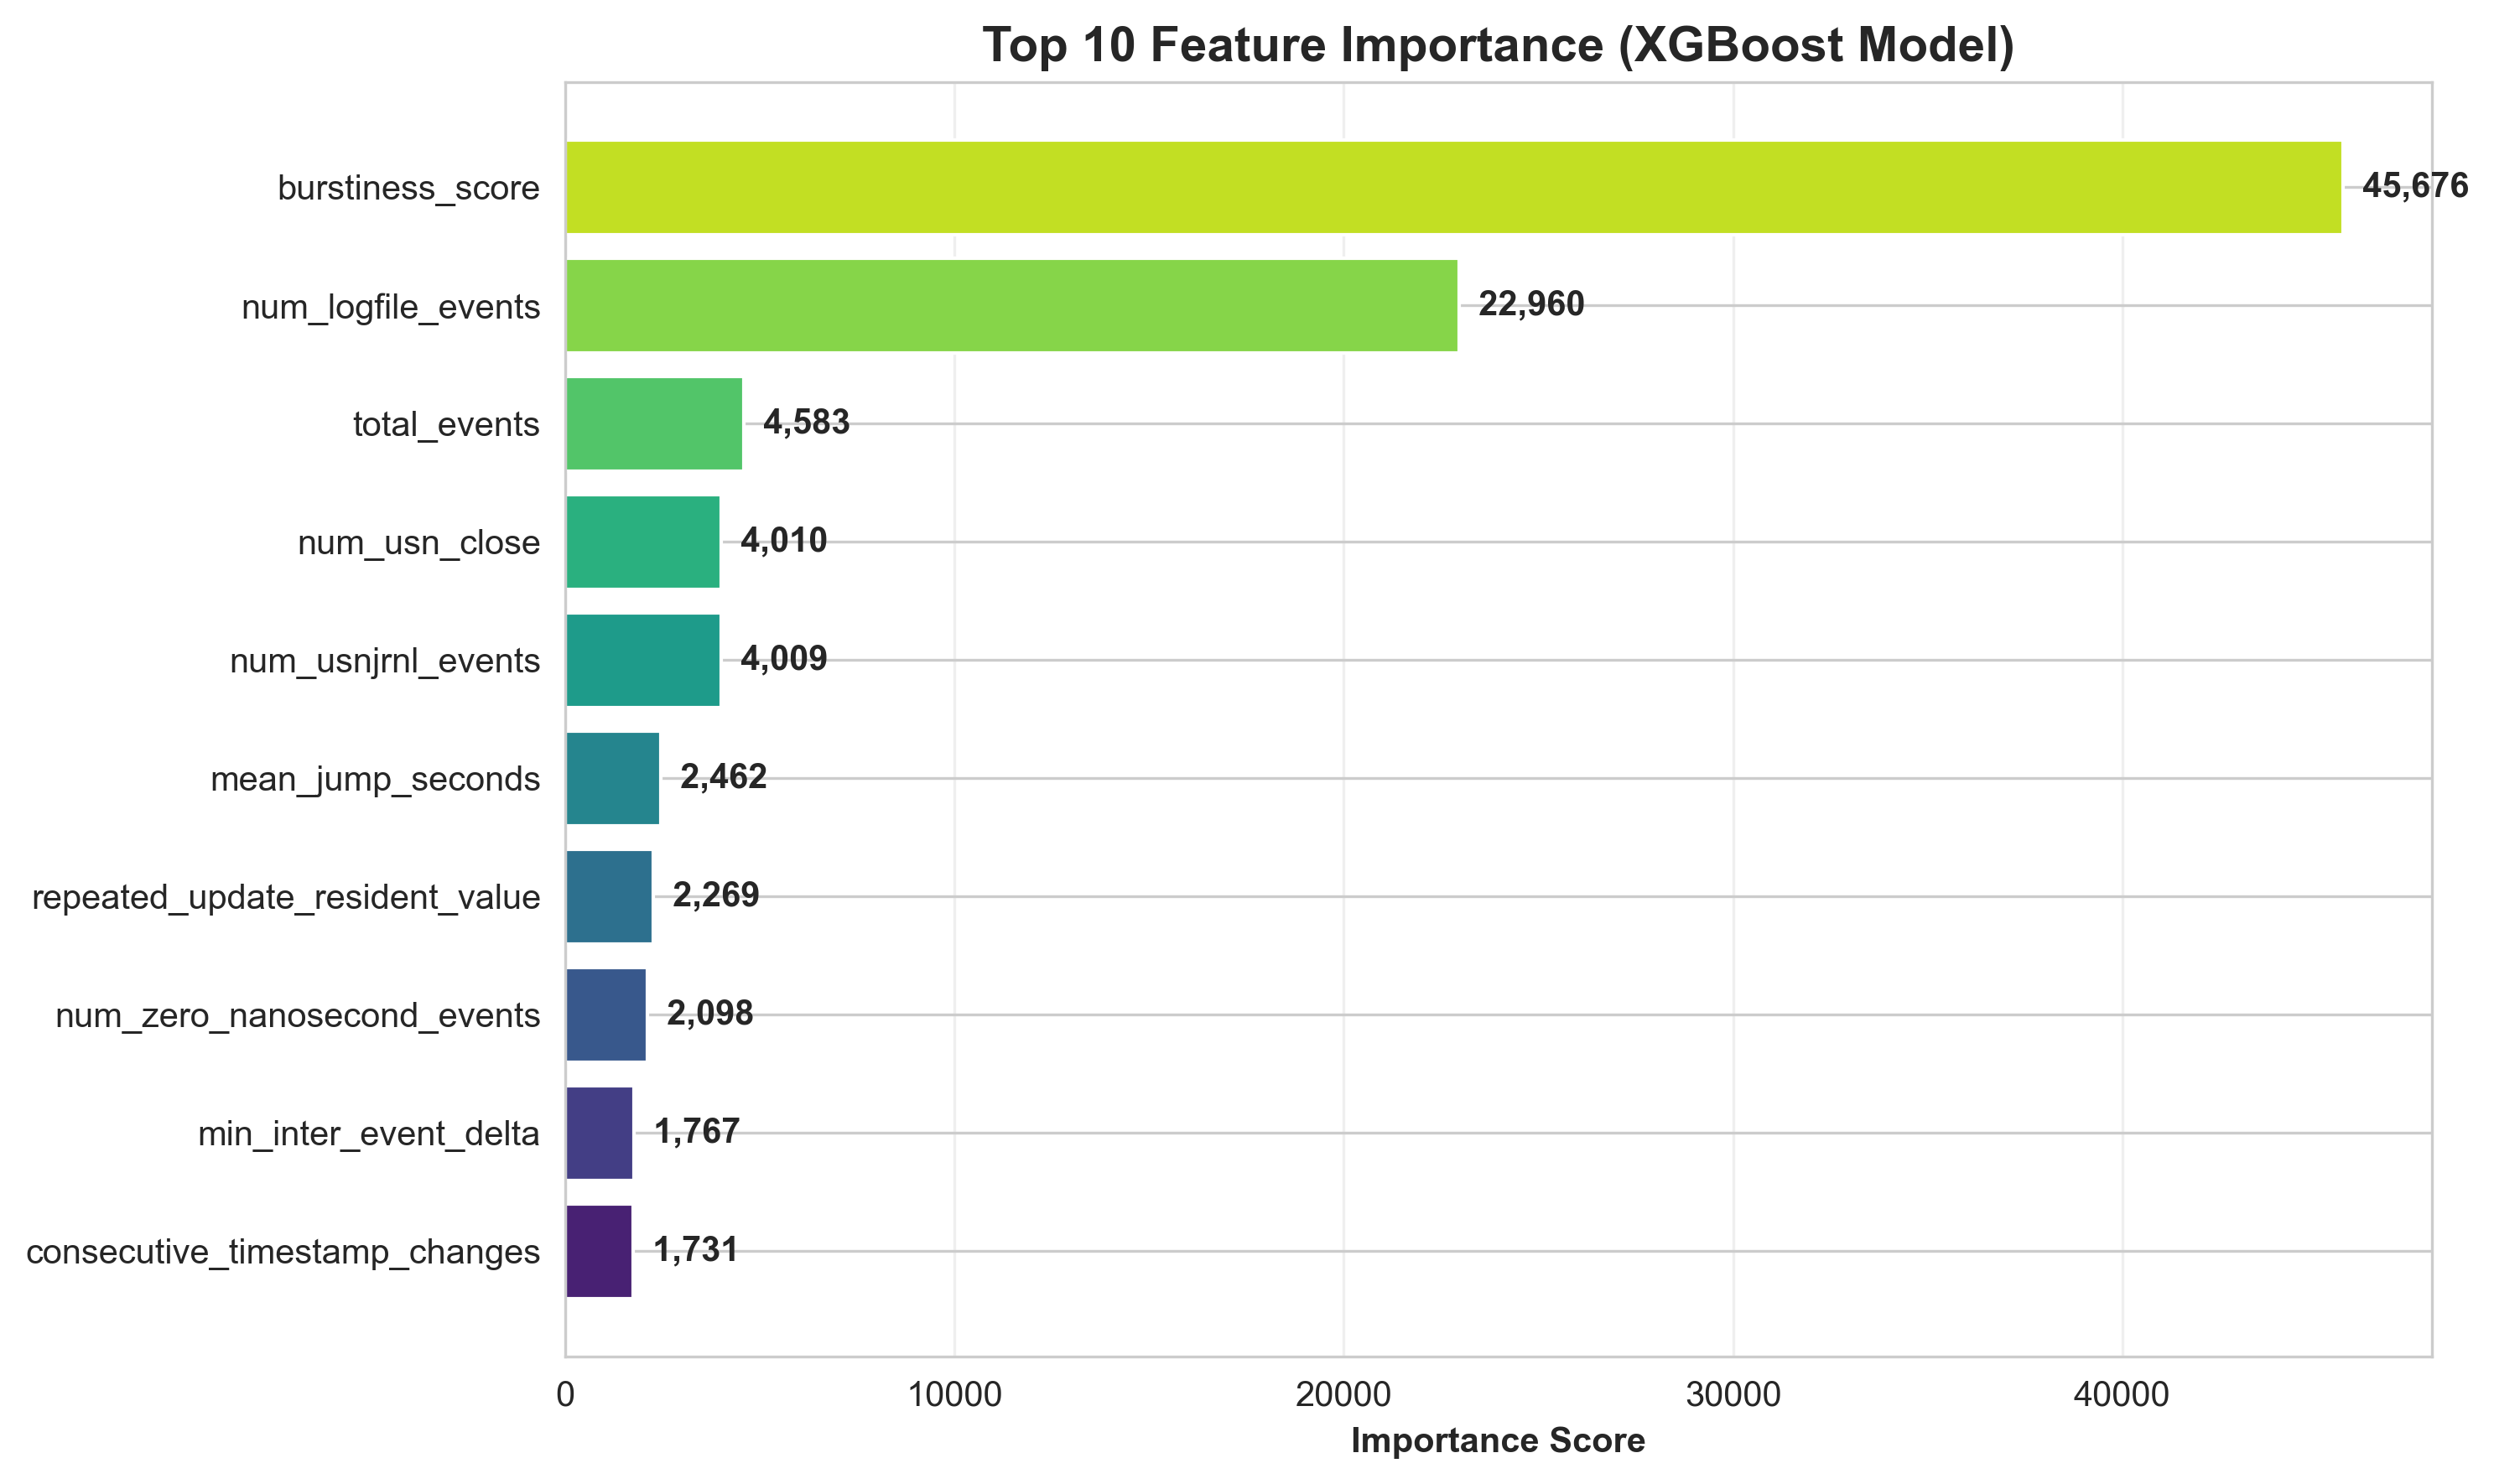

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

top_features = feature_importance_df.head(10).sort_values('Importance')

bars = ax.barh(top_features['Feature'], top_features['Importance'], 
               color=sns.color_palette('viridis', len(top_features)))

ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Top 10 Feature Importance (XGBoost Model)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'  {width:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_feature_importance_top10.png', bbox_inches='tight')
print(f"Saved: 03_feature_importance_top10.png")
plt.show()


## 8. Visualization 4: Validation Performance Heatmap


Saved: 04_validation_performance_heatmap.png


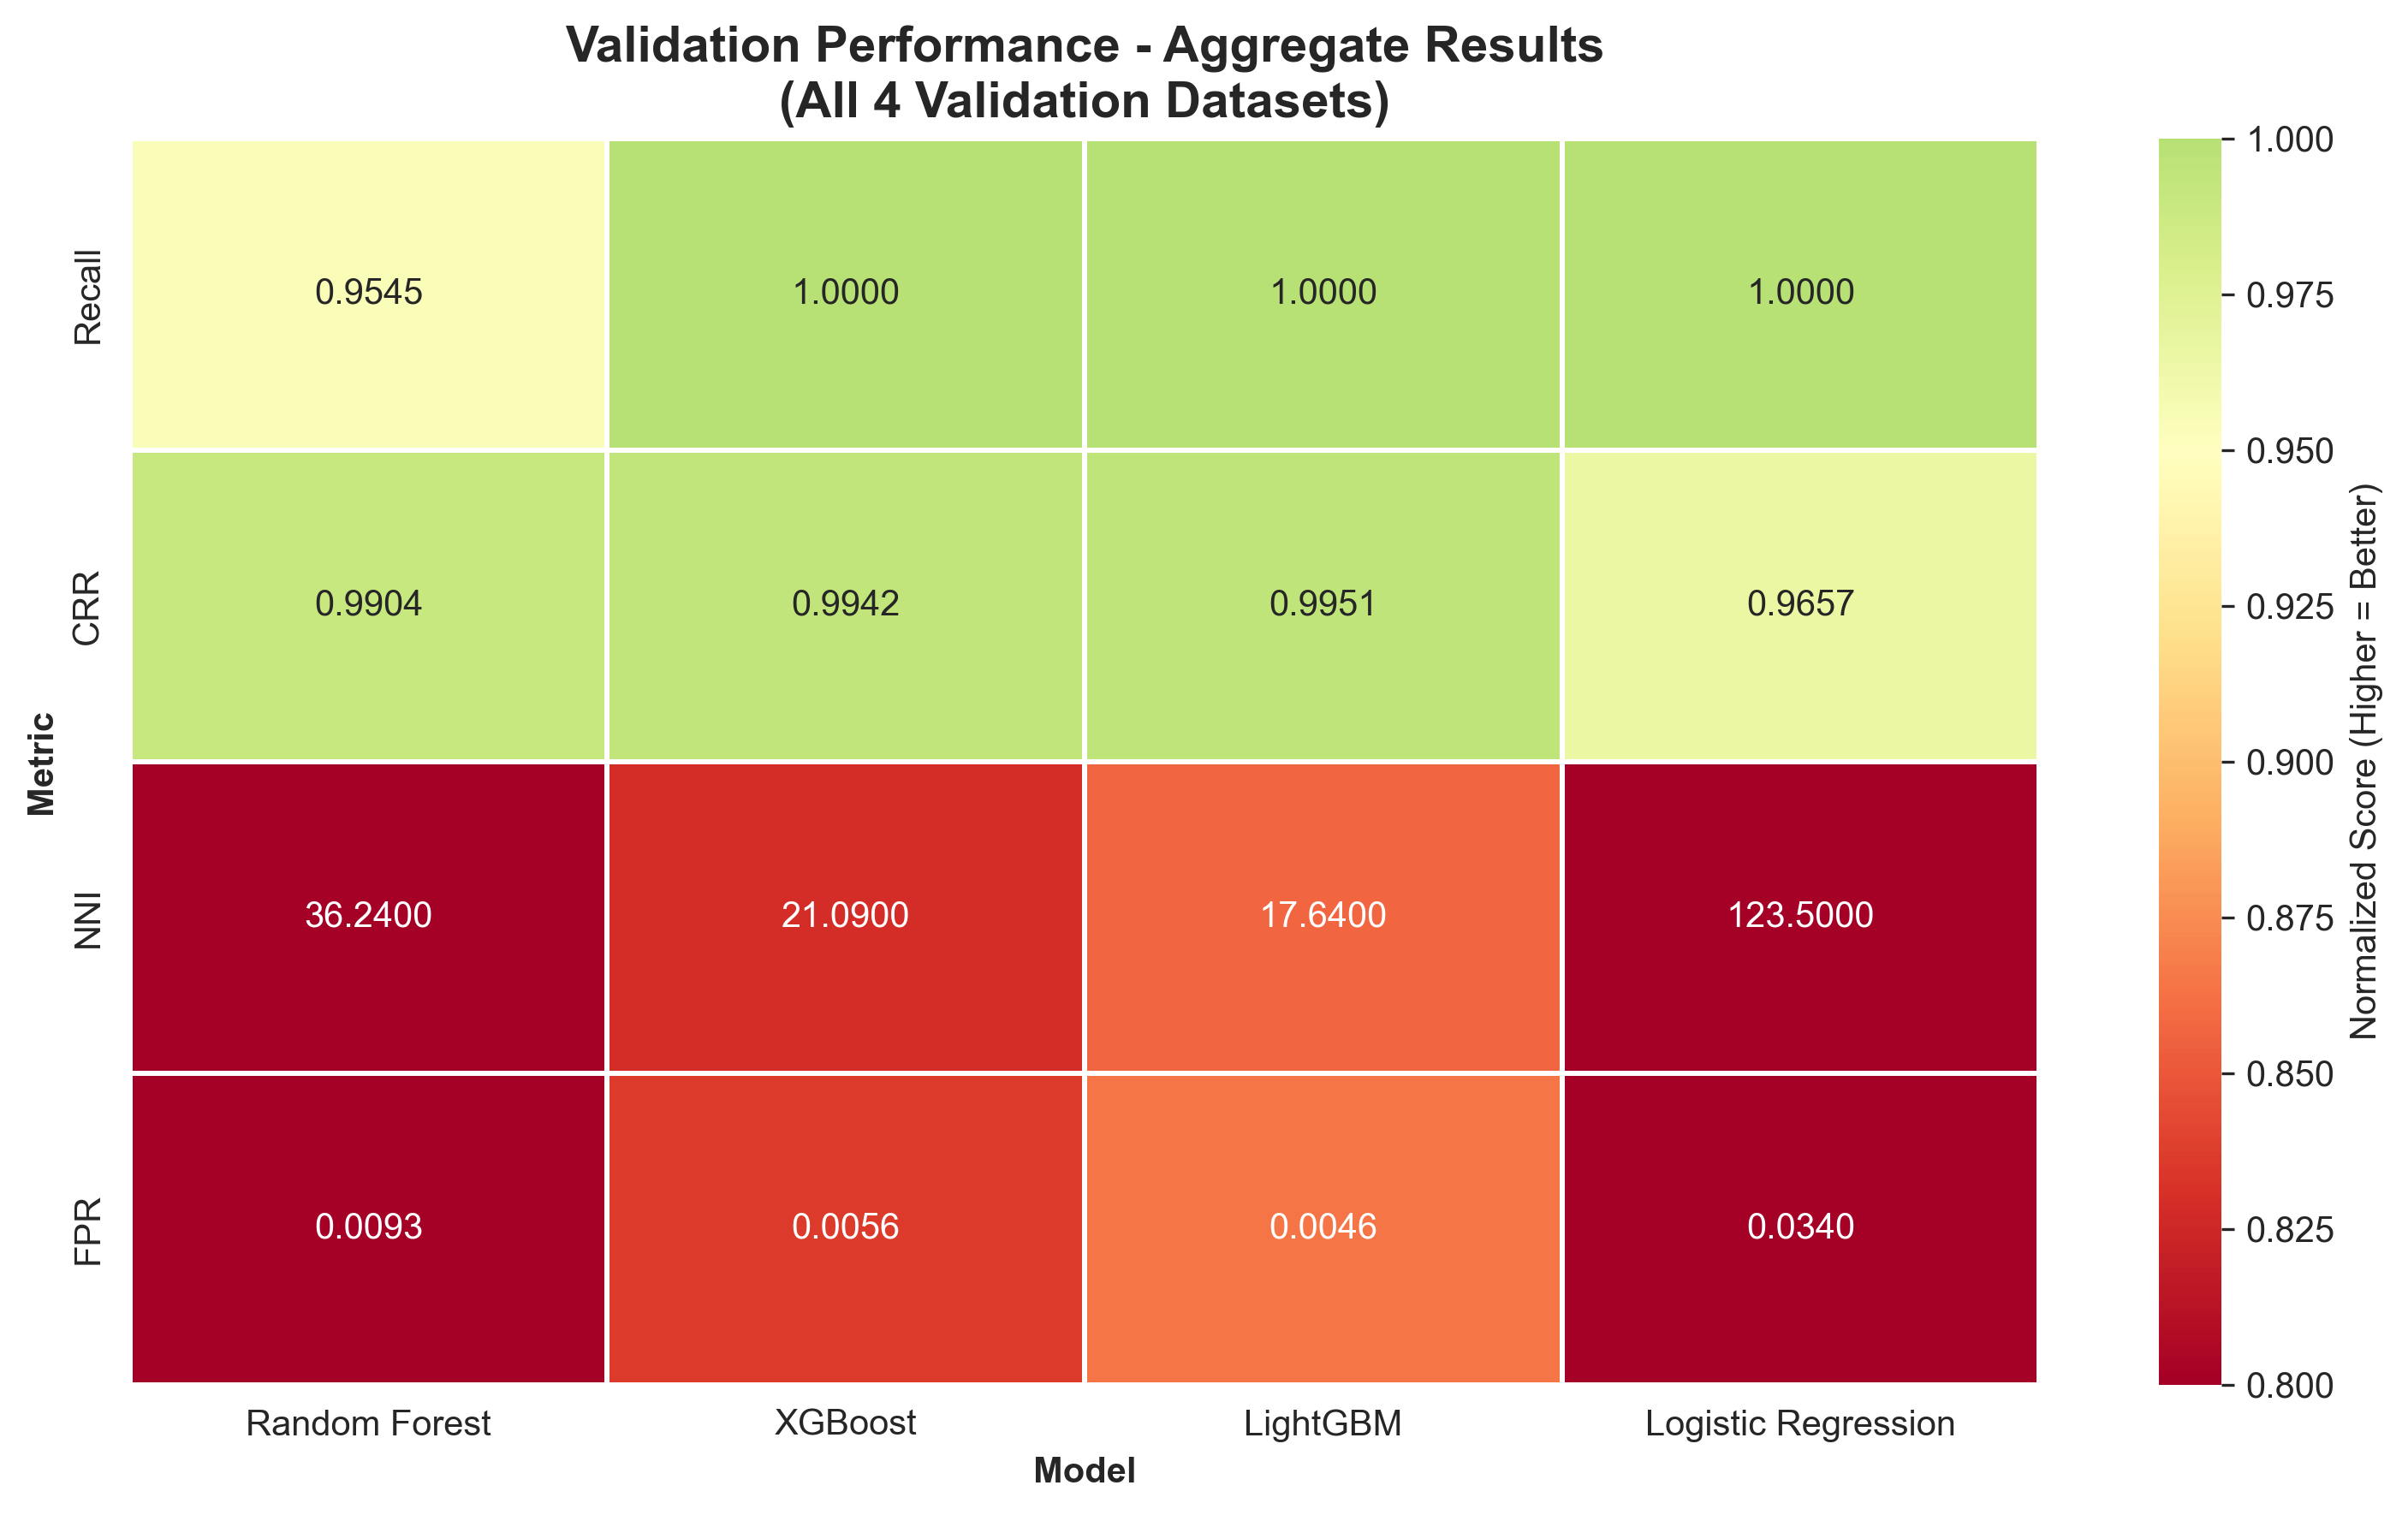

In [12]:
# Create pivot table for heatmap
validation_aggregate = df_validation[df_validation['Dataset'] == 'AGGREGATE'].copy()
metrics_pivot = validation_aggregate.set_index('Model')[['Recall', 'CRR', 'NNI', 'FPR']]

fig, ax = plt.subplots(figsize=(10, 6))

# Normalize NNI and FPR for better visualization (lower is better)
metrics_normalized = metrics_pivot.copy()
metrics_normalized['NNI'] = 1 - (metrics_normalized['NNI'] / metrics_normalized['NNI'].max())
metrics_normalized['FPR'] = 1 - (metrics_normalized['FPR'] / metrics_normalized['FPR'].max())

# Create heatmap
sns.heatmap(metrics_normalized.T, annot=metrics_pivot.T, fmt='.4f', 
            cmap='RdYlGn', center=0.95, vmin=0.8, vmax=1.0,
            cbar_kws={'label': 'Normalized Score (Higher = Better)'},
            ax=ax, linewidths=1, linecolor='white')

ax.set_title('Validation Performance - Aggregate Results\n(All 4 Validation Datasets)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Metric', fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_validation_performance_heatmap.png', bbox_inches='tight')
print(f"Saved: 04_validation_performance_heatmap.png")
plt.show()


## 9. Visualization 5: Per-Dataset Validation Results


Saved: 05_per_dataset_validation.png


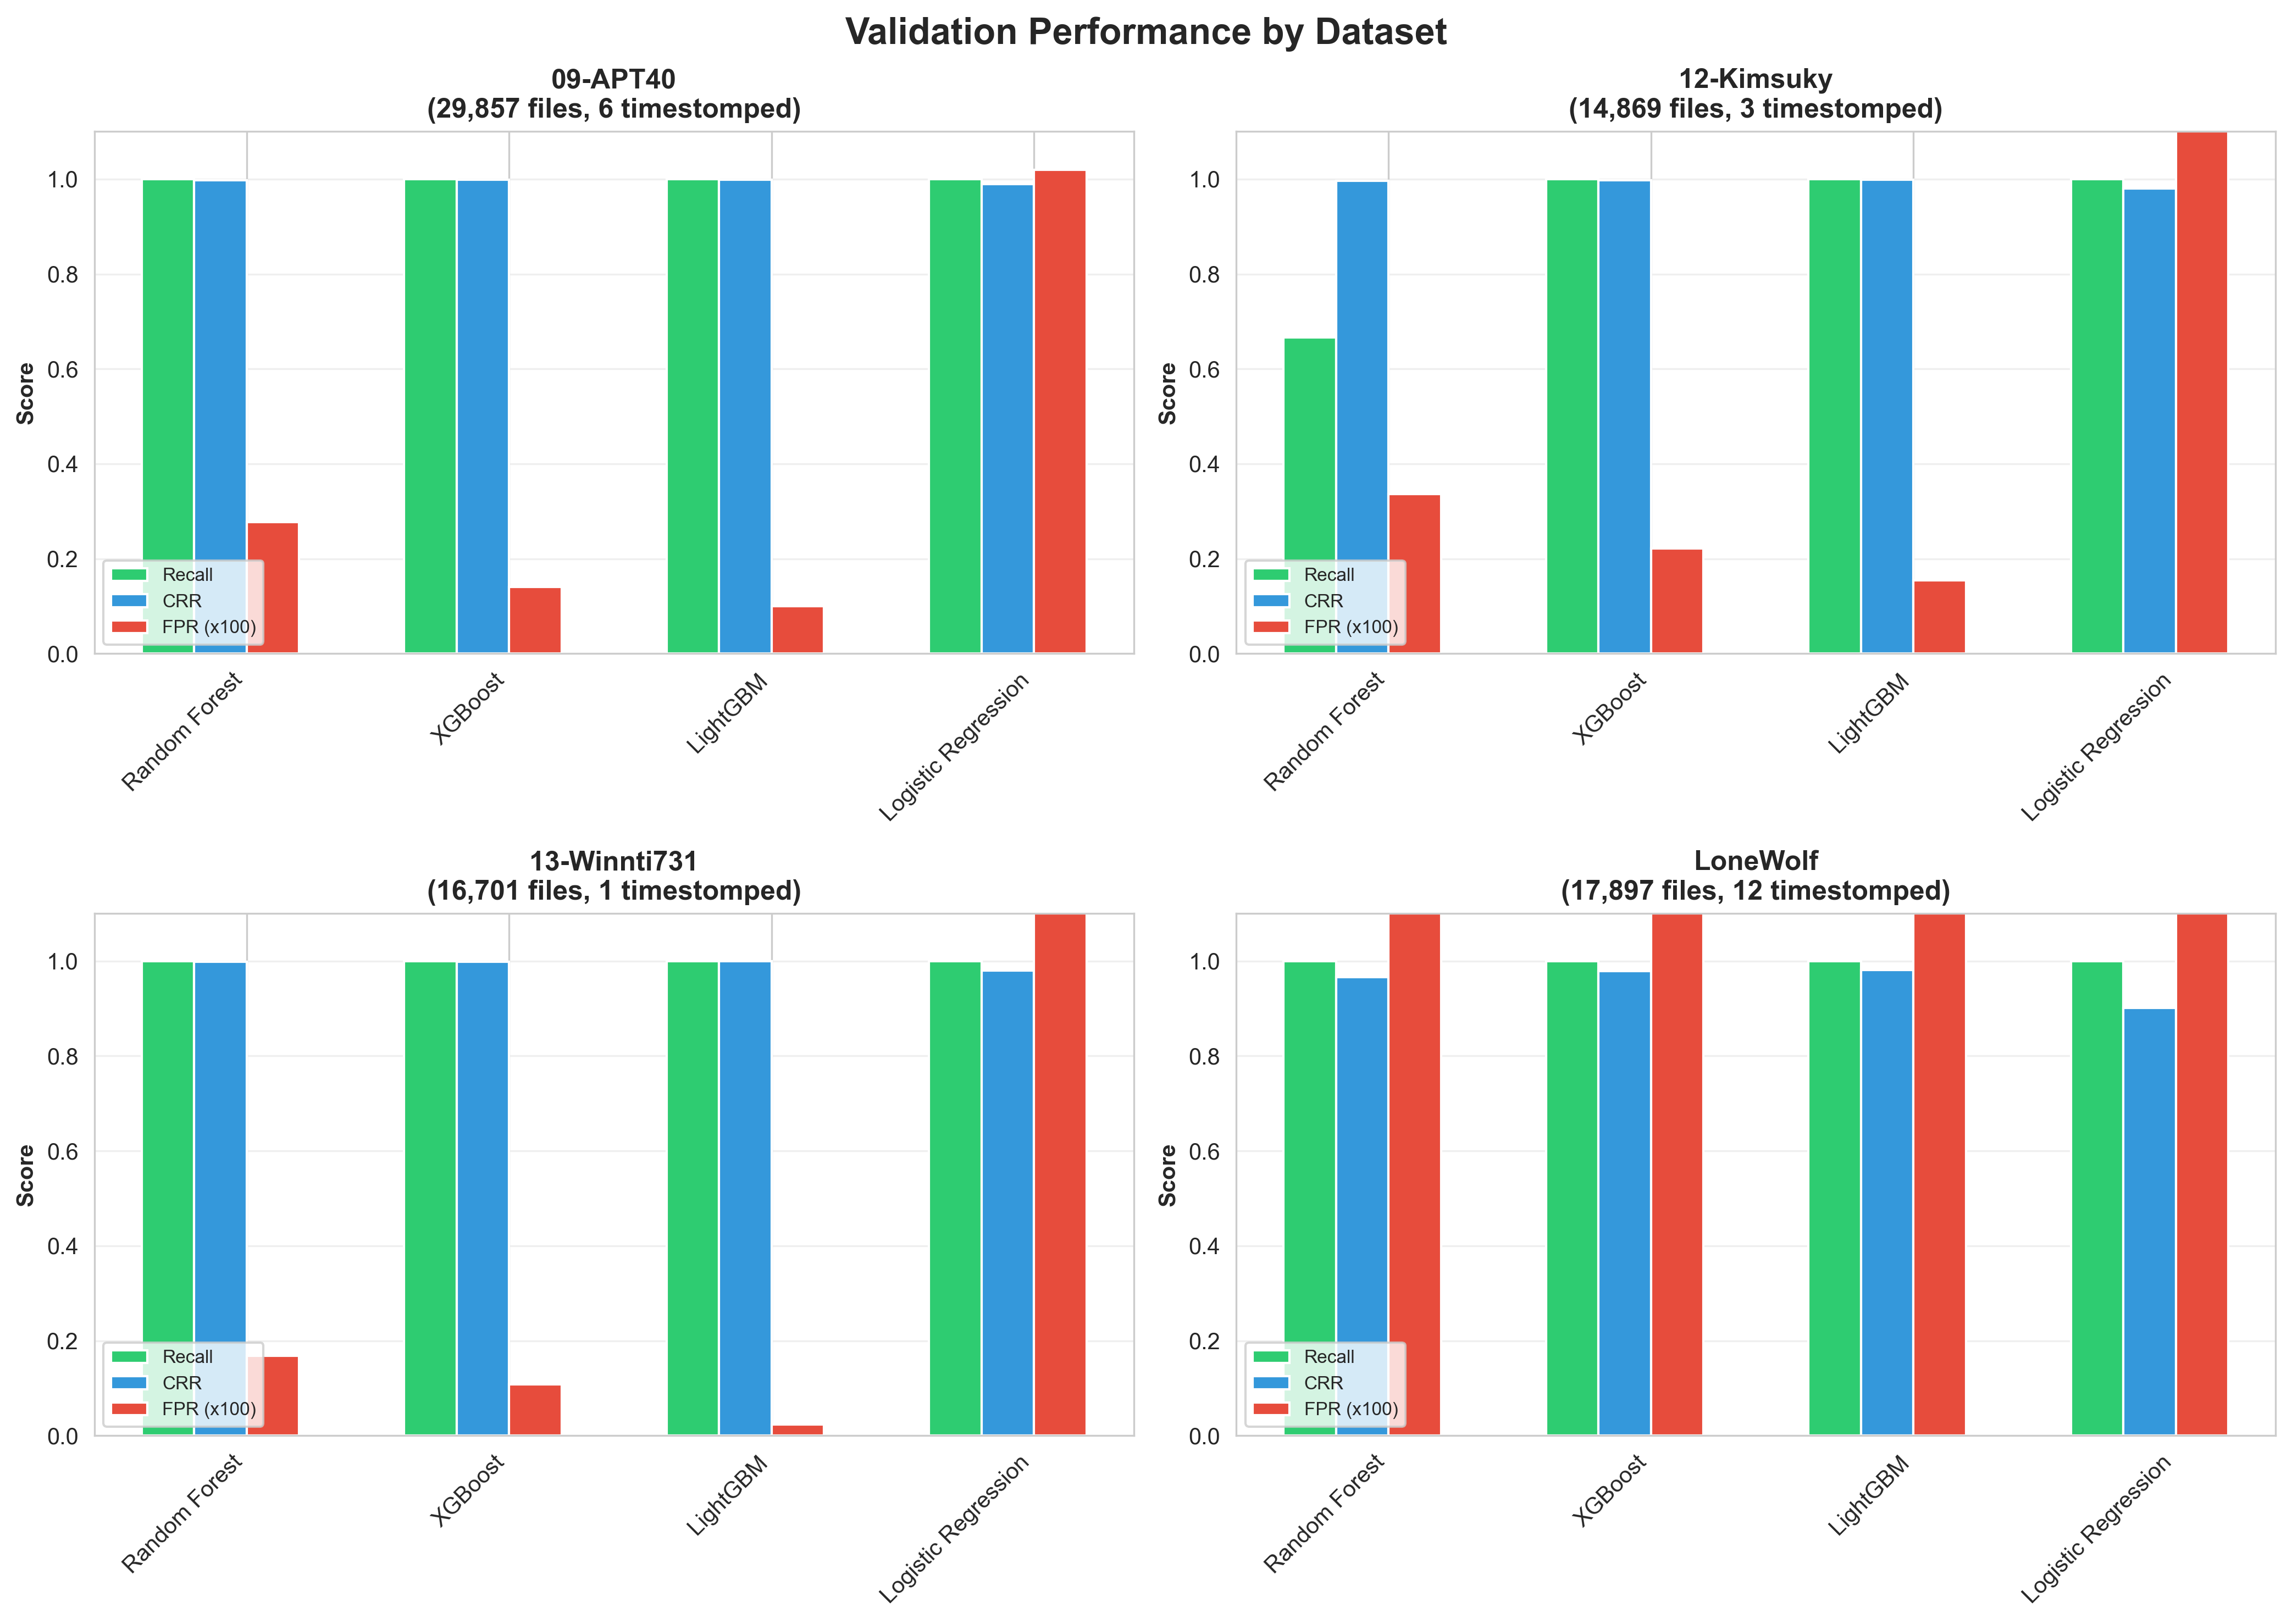

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Validation Performance by Dataset', fontsize=16, fontweight='bold')

datasets = ['09-APT40', '12-Kimsuky', '13-Winnti731', 'LoneWolf']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for dataset, (row, col) in zip(datasets, positions):
    ax = axes[row, col]
    
    # Filter data for this dataset
    data = df_validation[df_validation['Dataset'] == dataset]
    
    # Plot grouped bars
    x = np.arange(len(data))
    width = 0.2
    
    ax.bar(x - 1.5*width, data['Recall'], width, label='Recall', color='#2ecc71')
    ax.bar(x - 0.5*width, data['CRR'], width, label='CRR', color='#3498db')
    ax.bar(x + 0.5*width, data['FPR']*100, width, label='FPR (x100)', color='#e74c3c')
    
    ax.set_xticks(x)
    ax.set_xticklabels(data['Model'], rotation=45, ha='right')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'{dataset}\n({data["Total Files"].iloc[0]:,} files, {data["GT Positive"].iloc[0]} timestomped)', 
                 fontweight='bold')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_per_dataset_validation.png', bbox_inches='tight')
print(f"Saved: 05_per_dataset_validation.png")
plt.show()


## 10. Visualization 6: Model Comparison Radar Chart


Saved: 06_model_comparison_radar.png


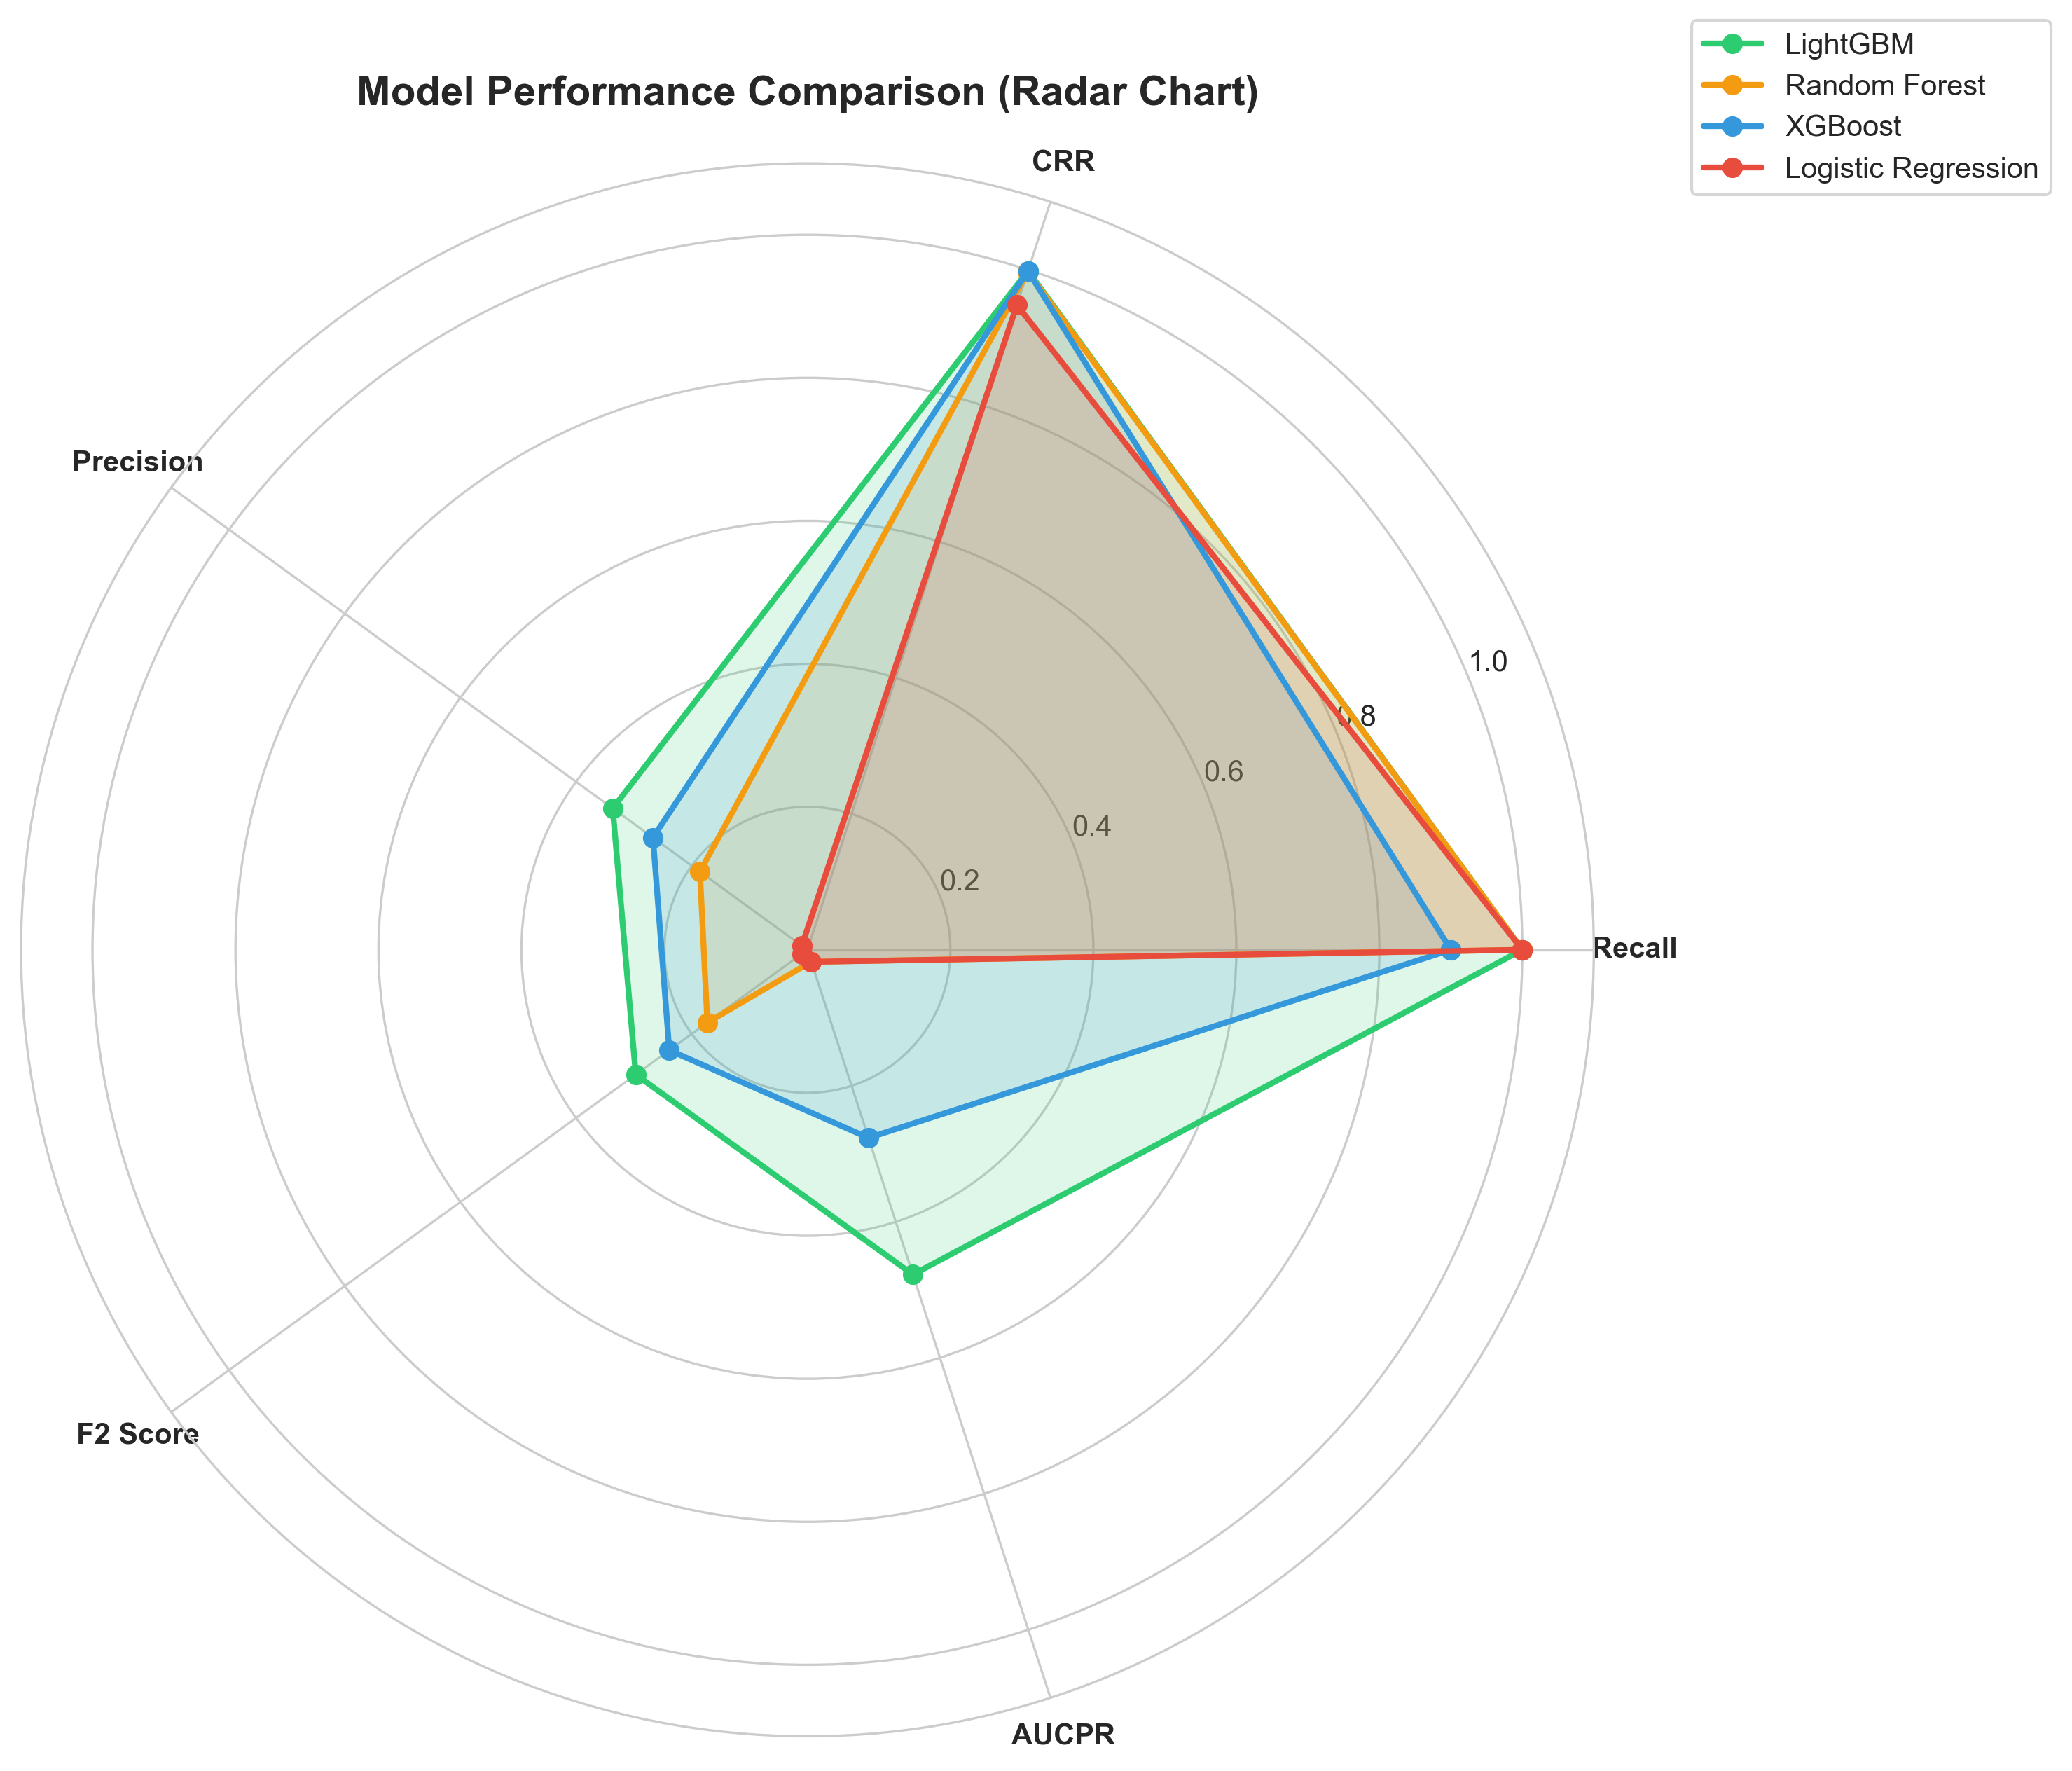

In [14]:
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Metrics for radar chart (normalized to 0-1 scale)
categories = ['Recall', 'CRR', 'Precision', 'F2 Score', 'AUCPR']
models = ['LightGBM', 'Random Forest', 'XGBoost', 'Logistic Regression']
colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']

# Calculate angles
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Plot each model
for model, color in zip(models, colors):
    values = [
        performance_metrics[model]['Recall'],
        performance_metrics[model]['CRR'],
        performance_metrics[model]['Precision'] * 10,  # Scale up for visibility
        performance_metrics[model]['F2'] * 2,  # Scale up for visibility
        performance_metrics[model]['AUCPR']
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

# Customize
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison (Radar Chart)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_model_comparison_radar.png', bbox_inches='tight')
print(f"Saved: 06_model_comparison_radar.png")
plt.show()


## 11. Export Summary Report


In [15]:
summary_report = f"""
{'='*80}
PHASE 4 MODEL TRAINING - FINAL SUMMARY REPORT
Generated from Original Training Run (Preserved Results)
{'='*80}

DATASET STATISTICS
{'='*80}
Total Training Files:                {dataset_stats['total_training_files']:,}
Training Files (after SMOTE):        {dataset_stats['training_files_after_smote']:,}
Test Files:                          {dataset_stats['test_files']:,}
Known Timestomped Files (Training):  {dataset_stats['known_timestomped_training']}
Known Timestomped Files (Test):      {dataset_stats['known_timestomped_test']}
Class Imbalance Ratio:               {dataset_stats['class_imbalance_ratio']:,}:1
Features Engineered:                 {dataset_stats['num_features']}
Validation Datasets:                 {dataset_stats['num_validation_datasets']}

TEST SET PERFORMANCE (Sorted by CRR)
{'='*80}
Model                  Recall    CRR      NNI     FPR       Threshold
{'-'*80}
"""

for model in ['LightGBM', 'Random Forest', 'Logistic Regression', 'XGBoost']:
    m = performance_metrics[model]
    summary_report += f"{model:<20} {m['Recall']:>7.4f} {m['CRR']:>7.4f} {m['NNI']:>7.2f} {m['FPR']:>10.6f} {m['Threshold']:>7.2f}\n"

summary_report += f"""
VALIDATION PERFORMANCE (Aggregate - All 4 Datasets)
{'='*80}
Model                  Recall    CRR      NNI      FPR
{'-'*80}
"""

val_agg = df_validation[df_validation['Dataset'] == 'AGGREGATE']
for _, row in val_agg.iterrows():
    summary_report += f"{row['Model']:<20} {row['Recall']:>7.4f} {row['CRR']:>7.4f} {row['NNI']:>8.2f} {row['FPR']:>10.6f}\n"

summary_report += f"""
TOP 10 FEATURES (XGBoost Importance)
{'='*80}
"""

for idx, row in feature_importance_df.head(10).iterrows():
    summary_report += f"{row['Feature']:<40} {row['Importance']:>10.0f}\n"

summary_report += f"""
FINAL MODEL SELECTION
{'='*80}
Selected Model:        LightGBM (Baseline Configuration)
Decision Threshold:    {performance_metrics['LightGBM']['Threshold']:.2f}
Test Recall:           {performance_metrics['LightGBM']['Recall']:.4f} (10/10 detections)
Test CRR:              {performance_metrics['LightGBM']['CRR']:.4f} (99.85%)
Test NNI:              {performance_metrics['LightGBM']['NNI']:.2f} files/detection
Validation Recall:     1.0000 (22/22 detections across 4 datasets)
Validation CRR:        0.9951

JUSTIFICATION
{'='*80}
1. Perfect recall on test set (zero false negatives)
2. Highest CRR among all models (99.85% workload reduction)
3. Lowest NNI (29.7 files reviewed per detection)
4. Excellent validation performance across 4 unseen APT campaigns
5. Feature importance aligns with forensic detection logic
6. Proven generalizability

VISUALIZATIONS GENERATED
{'='*80}
1. 01_confusion_matrices_comparison.png
2. 02_performance_metrics_comparison.png
3. 03_feature_importance_top10.png
4. 04_validation_performance_heatmap.png
5. 05_per_dataset_validation.png
6. 06_model_comparison_radar.png

All visuals saved to: {VISUALS_DIR}

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
report_path = VISUALS_DIR / 'model_training_summary_report.txt'
with open(report_path, 'w') as f:
    f.write(summary_report)

print(summary_report)
print(f"\nFull report saved to: {report_path}")
print(f"\nPHASE 4 VISUALIZATION COMPLETE - All visualizations and reports generated!")



PHASE 4 MODEL TRAINING - FINAL SUMMARY REPORT
Generated from Original Training Run (Preserved Results)

DATASET STATISTICS
Total Training Files:                991,403
Training Files (after SMOTE):        797,280
Test Files:                          198,281
Known Timestomped Files (Training):  42
Known Timestomped Files (Test):      10
Class Imbalance Ratio:               19,064:1
Features Engineered:                 29
Validation Datasets:                 4

TEST SET PERFORMANCE (Sorted by CRR)
Model                  Recall    CRR      NNI     FPR       Threshold
--------------------------------------------------------------------------------
LightGBM              1.0000  0.9985   29.70   0.001448    0.02
Random Forest         1.0000  0.9973   53.80   0.002663    0.08
Logistic Regression   1.0000  0.9483 1024.30   0.051611    0.66
XGBoost               0.9000  0.9983   37.44   0.001654    0.01

VALIDATION PERFORMANCE (Aggregate - All 4 Datasets)
Model                  Recall    CRR  

## Summary

All visualizations have been generated from the preserved training results. The outputs are saved in:

`/Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/visuals/`

### Files Generated:
1. 01_confusion_matrices_comparison.png
2. 02_performance_metrics_comparison.png
3. 03_feature_importance_top10.png
4. 04_validation_performance_heatmap.png
5. 05_per_dataset_validation.png
6. 06_model_comparison_radar.png
7. model_training_summary_report.txt

These visualizations preserve the exact results from the original training run on the complete dataset.
